In [1]:
import pandas as pd

# AAP daily OHLCV; path is relative to this notebook's working directory
csv_path = "./individual_stocks_5yr/AAP_data.csv"
df = pd.read_csv(csv_path, parse_dates=["date"])

# Quick sanity check: shape, dtypes, first rows
print(df.shape)
print(df.dtypes)
df.head()

(1259, 7)
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
Name              object
dtype: object


,date,open,high,low,close,volume,Name
0,2013-02-08,78.34,79.72,78.0100,78.90,1298137,AAP
1,2013-02-11,78.65,78.91,77.2300,78.39,758016,AAP
2,2013-02-12,78.39,78.63,77.5132,78.60,876859,AAP
3,2013-02-13,78.90,79.13,77.8500,78.97,1038574,AAP
4,2013-02-14,78.66,79.72,78.5850,78.84,1005376,AAP


In [2]:
import pandas as pd

# Null/NaN vs empty strings are separate: "" is not NaN in object columns
null_per_col = df.isna().sum()
print("Null / NaN count per column:")
print(null_per_col.to_string())

cols_with_nulls = null_per_col[null_per_col > 0]
print()
if len(cols_with_nulls):
    print("Columns with at least one missing value:")
    print(cols_with_nulls.to_string())
else:
    print("No null or NaN in any column (all counts are 0).")

# Empty = whitespace-stripped string length 0 (skip numeric/datetime dtypes)
def _n_empty_strings(col):
    if pd.api.types.is_numeric_dtype(col) or pd.api.types.is_datetime64_any_dtype(col):
        return 0
    return col.astype(str).str.strip().eq("").sum()

empty_per_col = df.apply(_n_empty_strings)
print()
print("Empty string count per column (after strip):")
print(empty_per_col.to_string())

cols_with_empty = empty_per_col[empty_per_col > 0]
print()
if len(cols_with_empty):
    print("Columns with at least one empty string:")
    print(cols_with_empty.to_string())
else:
    print("No empty strings in scanned text columns (all counts are 0).")



Null / NaN count per column:
date      0
open      0
high      0
low       0
close     0
volume    0
Name      0

No null or NaN in any column (all counts are 0).

Empty string count per column (after strip):
date      0
open      0
high      0
low       0
close     0
volume    0
Name      0

No empty strings in scanned text columns (all counts are 0).


In [3]:
# --- Imports: numerics, tables, and sklearn (linear models, metrics, CV, robust scaling) ---
import numpy as np
import pandas as pd

from sklearn.linear_model import HuberRegressor, LogisticRegression, Ridge, RidgeCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, train_test_split
from sklearn.preprocessing import RobustScaler

# --- Goal ---
# Regress next-day simple return; classify next day up vs not. Ridge and Huber share X; logistic uses the same X.
# Extra columns (e.g. volatility alias) support the correlation heatmap; listed names are the model inputs.

# --- Step 1: Regularization grid and time-ordered CV ---
# ridge_alphas: L2 strengths to try. ridge_cv_splitter: train on the past, validate on a future chunk (5 folds).
ridge_alphas = [0.0001, 0.001, 0.01, 0.1, 1, 1.5, 5, 10, 12, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 500, 1000, 2000, 3000]
ridge_cv_splitter = TimeSeriesSplit(n_splits=5)

# --- Step 2: Build targets and scale-free features (only information available through today's close) ---
df_multi = df.copy()
# Target: simple return from today's close to tomorrow's close (last row has no tomorrow — dropped later).
df_multi["return_next"] = (
    (df_multi["close"].shift(-1) - df_multi["close"]) / df_multi["close"]
)
df_multi["daily_return"] = df_multi["close"].pct_change()
# Intraday range vs close (decimal-style units, comparable to returns).
df_multi["high_low_range_over_close"] = (df_multi["high"] - df_multi["low"]) / df_multi["close"]
# True range vs close: incorporates gap vs prior close, not only the session high-low bar.
_prev_close = df_multi["close"].shift(1)
_true_range = pd.concat(
    [
        df_multi["high"] - df_multi["low"],
        (df_multi["high"] - _prev_close).abs(),
        (df_multi["low"] - _prev_close).abs(),
    ],
    axis=1,
).max(axis=1)
df_multi["true_range_over_close"] = _true_range / df_multi["close"]

df_multi["intraday_return"] = (df_multi["close"] - df_multi["open"]) / df_multi["open"]
df_multi["overnight_gap_over_prior_close"] = (df_multi["open"] - df_multi["close"].shift(1)) / df_multi["close"].shift(1)
df_multi["log_volume"] = np.log1p(df_multi["volume"])
# Volume today vs its 20-day average (dimensionless; "relative volume").
df_multi["relative_volume_20d"] = df_multi["volume"] / df_multi["volume"].rolling(
    20, min_periods=20
).mean()

df_multi["prev_return"] = df_multi["daily_return"].shift(1)
df_multi["realized_volatility_5d"] = df_multi["daily_return"].rolling(window=5, min_periods=5).std()
df_multi["volatility_5d"] = df_multi["realized_volatility_5d"]  # duplicate label for correlation EDA
df_multi["volume_momentum"] = df_multi["log_volume"] / df_multi["log_volume"].rolling(5).mean()

# --- Step 3: Feature list for X (everything below must be non-NaN after dropna) ---
feature_names = [
    "daily_return",
    "true_range_over_close",
    "high_low_range_over_close",
    "intraday_return",
    "overnight_gap_over_prior_close",
    "relative_volume_20d",
    "realized_volatility_5d",
    "prev_return",
    "log_volume",
    "volume_momentum",
]

# Pearson correlations for EDA: all model inputs plus volatility alias and the raw target.
correlation_columns = feature_names + ["volatility_5d", "return_next"]
correlation_matrix = df_multi[correlation_columns].corr()

# Rows need valid target, gaps, rolling windows (vol, relative volume), and lags.
drop_subset = [
    "return_next",
    "daily_return",
    "overnight_gap_over_prior_close",
    "realized_volatility_5d",
    "true_range_over_close",
    "high_low_range_over_close",
    "relative_volume_20d",
    "prev_return",
    "log_volume",
    "volume_momentum",
]
df_multi = df_multi.dropna(subset=drop_subset)

features_raw = df_multi[feature_names].to_numpy()
target_next_day_return = df_multi["return_next"].to_numpy().reshape(-1, 1)
# Classification label: 1 if next-day return > 0 (same rows as regression).
target_next_day_up = (df_multi["return_next"] > 0).astype(np.int8).to_numpy().reshape(-1, 1)
dates_all = pd.to_datetime(df_multi["date"])

# --- Step 4: Train/test split (chronological): last 20% of rows = test; no shuffling ---
(
    features_train_raw,
    features_test_raw,
    target_train,
    target_test,
    target_train_direction,
    target_test_direction,
    dates_train,
    dates_test,
) = train_test_split(
    features_raw,
    target_next_day_return,
    target_next_day_up,
    dates_all,
    test_size=0.2,
    shuffle=False,
)

# --- Step 5: Scale features with train median/IQR; apply the same transform to test (no test leakage) ---
robust_feature_scaler = RobustScaler()
features_train = robust_feature_scaler.fit_transform(features_train_raw)
features_test = robust_feature_scaler.transform(features_test_raw)

# --- Step 6: Ridge — CV RMSE vs alpha (for the plot), then RidgeCV picks alpha and refits on full train ---
ridge_cv_rmse_by_alpha = []
for ridge_alpha in ridge_alphas:
    neg_mse_scores = cross_val_score(
        Ridge(alpha=ridge_alpha, fit_intercept=True),
        features_train,
        target_train.ravel(),
        cv=ridge_cv_splitter,
        scoring="neg_mean_squared_error",
    )
    mse_mean = -neg_mse_scores.mean()
    ridge_cv_rmse_by_alpha.append(np.sqrt(mse_mean))

ridge_cv = RidgeCV(alphas=ridge_alphas, cv=ridge_cv_splitter, fit_intercept=True)
ridge_cv.fit(features_train, target_train.ravel())

predictions_train = ridge_cv.predict(features_train).reshape(-1, 1)
predictions_test = ridge_cv.predict(features_test).reshape(-1, 1)

r2_train = r2_score(target_train, predictions_train)
r2_test = r2_score(target_test, predictions_test)
rmse_train = float(np.sqrt(mean_squared_error(target_train, predictions_train)))
rmse_test = float(np.sqrt(mean_squared_error(target_test, predictions_test)))

residuals_test = (target_test - predictions_test).ravel()

# --- Step 7: Huber regression — robust linear fit; reuse Ridge's alpha as L2 for a rough comparison ---
huber_regressor = HuberRegressor(max_iter=200, alpha=ridge_cv.alpha_)
huber_regressor.fit(features_train, target_train.ravel())
predictions_test_huber = huber_regressor.predict(features_test).reshape(-1, 1)
rmse_test_huber = float(np.sqrt(mean_squared_error(target_test, predictions_test_huber)))

# --- Step 8: Logistic regression — P(next day up); balanced classes; test metrics + mean CV ROC-AUC on train folds ---
logistic_regression = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs",
)
logistic_regression.fit(features_train, target_train_direction.ravel())
logistic_predictions_test = logistic_regression.predict(features_test)
logistic_proba_test = logistic_regression.predict_proba(features_test)[:, 1]
logistic_accuracy_test = float(accuracy_score(target_test_direction, logistic_predictions_test))
logistic_balanced_accuracy_test = float(
    balanced_accuracy_score(target_test_direction, logistic_predictions_test)
)
if len(np.unique(target_test_direction)) < 2:
    logistic_roc_auc_test = float("nan")
else:
    logistic_roc_auc_test = float(roc_auc_score(target_test_direction.ravel(), logistic_proba_test))
logistic_cv_roc_auc_mean = float(
    np.mean(
        cross_val_score(
            LogisticRegression(max_iter=3000, class_weight="balanced", solver="lbfgs"),
            features_train,
            target_train_direction.ravel(),
            cv=ridge_cv_splitter,
            scoring="roc_auc",
        )
    )
)



Correlation matrix (rounded):
                                daily_return  true_range_over_close  \
daily_return                           1.000                  0.005   
true_range_over_close                  0.005                  1.000   
high_low_range_over_close             -0.031                  0.873   
intraday_return                        0.748                  0.003   
overnight_gap_over_prior_close         0.680                 -0.008   
relative_volume_20d                    0.013                  0.665   
realized_volatility_5d                 0.061                  0.473   
prev_return                           -0.019                 -0.044   
log_volume                             0.013                  0.600   
volume_momentum                        0.024                  0.475   
volatility_5d                          0.061                  0.473   
return_next                           -0.019                 -0.004   

                                high_low_range

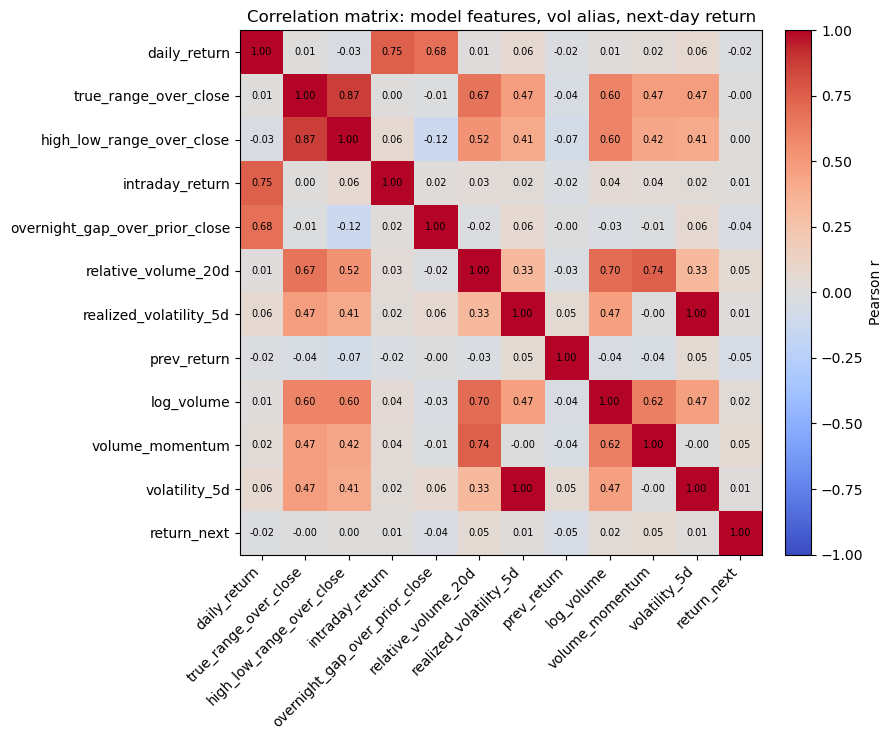

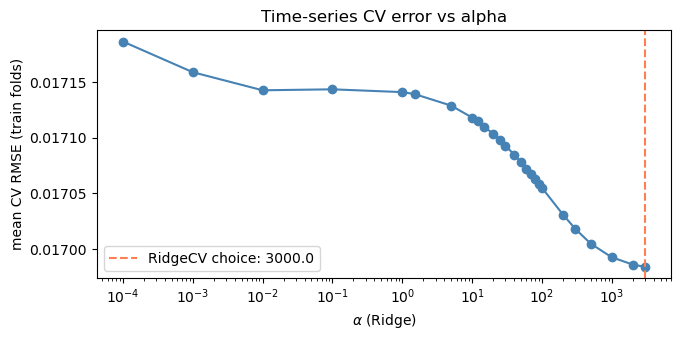

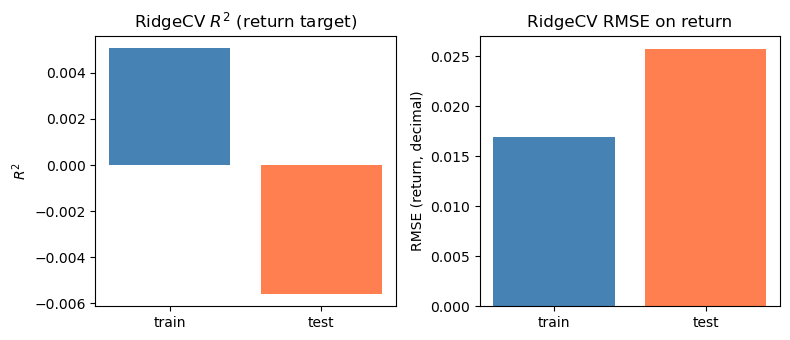

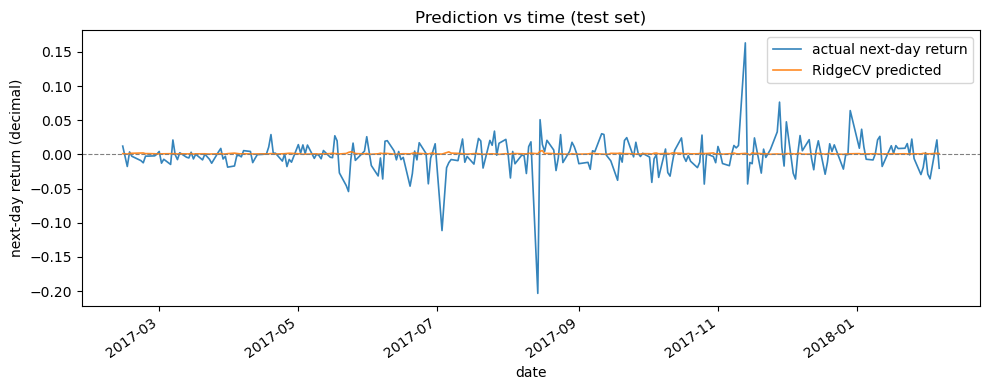

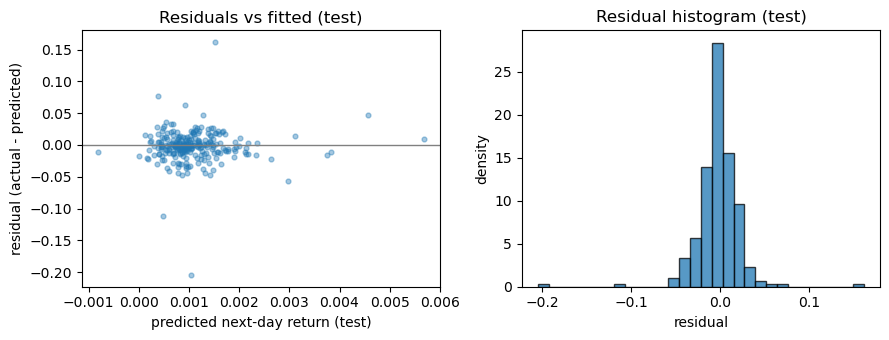

In [4]:
import matplotlib.pyplot as plt

# --- Uses setup: correlation_matrix, ridge_cv, predictions_*, etc. ---
# Quick pairwise view (linear relationships only — my model is linear too).

print("Correlation matrix (rounded):")
print(correlation_matrix.round(3))

fig_corr, ax_corr = plt.subplots(figsize=(9, 7.5))
heatmap = ax_corr.imshow(
    correlation_matrix.values,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto",
)
ax_corr.set_xticks(range(len(correlation_matrix.columns)))
ax_corr.set_yticks(range(len(correlation_matrix.columns)))
ax_corr.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax_corr.set_yticklabels(correlation_matrix.columns)
for row_idx in range(len(correlation_matrix)):
    for col_idx in range(len(correlation_matrix)):
        ax_corr.text(
            col_idx,
            row_idx,
            f"{correlation_matrix.values[row_idx, col_idx]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
        )
fig_corr.colorbar(heatmap, ax=ax_corr, fraction=0.046, pad=0.04, label="Pearson r")
ax_corr.set_title("Correlation matrix: model features, vol alias, next-day return")
plt.tight_layout()
plt.show()

# How cross validation error moves as I increase regularization
fig_alpha, ax_alpha = plt.subplots(figsize=(7, 3.5))
ax_alpha.semilogx(ridge_alphas, ridge_cv_rmse_by_alpha, "o-", color="steelblue")
ax_alpha.axvline(ridge_cv.alpha_, color="coral", ls="--", label=f"RidgeCV choice: {ridge_cv.alpha_}")
ax_alpha.set_xlabel(r"$\alpha$ (Ridge)")
ax_alpha.set_ylabel("mean CV RMSE (train folds)")
ax_alpha.set_title("Time-series CV error vs alpha")
ax_alpha.legend()
plt.tight_layout()
plt.show()

fig_metrics, axes_metrics = plt.subplots(1, 2, figsize=(8, 3.5))
axes_metrics[0].bar(["train", "test"], [r2_train, r2_test], color=["steelblue", "coral"])
axes_metrics[0].set_ylabel(r"$R^2$")
axes_metrics[0].set_title(r"RidgeCV $R^2$ (return target)")
axes_metrics[1].bar(["train", "test"], [rmse_train, rmse_test], color=["steelblue", "coral"])
axes_metrics[1].set_ylabel("RMSE (return, decimal)")
axes_metrics[1].set_title("RidgeCV RMSE on return")
plt.tight_layout()
plt.show()

fig_time, ax_time = plt.subplots(figsize=(10, 4))
ax_time.plot(dates_test, target_test.ravel(), label="actual next-day return", lw=1.2, alpha=0.9)
ax_time.plot(
    dates_test,
    predictions_test.ravel(),
    label="RidgeCV predicted",
    lw=1.2,
    alpha=0.9,
)
ax_time.axhline(0.0, color="gray", lw=0.8, ls="--")
ax_time.set_xlabel("date")
ax_time.set_ylabel("next-day return (decimal)")
ax_time.set_title("Prediction vs time (test set)")
ax_time.legend()
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Residuals: vs fitted (pattern/heteroscedasticity) and histogram (marginal distribution) — no Q-Q tail plot.
fig_resid, axes_resid = plt.subplots(1, 2, figsize=(9, 3.5))
axes_resid[0].scatter(predictions_test.ravel(), residuals_test, s=12, alpha=0.4)
axes_resid[0].axhline(0.0, color="gray", lw=1)
axes_resid[0].set_xlabel("predicted next-day return (test)")
axes_resid[0].set_ylabel("residual (actual - predicted)")
axes_resid[0].set_title("Residuals vs fitted (test)")
axes_resid[1].hist(residuals_test, bins=30, edgecolor="black", alpha=0.75, density=True)
axes_resid[1].set_xlabel("residual")
axes_resid[1].set_ylabel("density")
axes_resid[1].set_title("Residual histogram (test)")
plt.tight_layout()
plt.show()



In [5]:
print(f"Ridge alphas tried: {ridge_alphas}")
print(f"RidgeCV selected alpha: {ridge_cv.alpha_}")
print(f"intercept: {ridge_cv.intercept_:.6f}")
for name, coef in zip(feature_names, ridge_cv.coef_):
    print(f"  coef[{name}]: {coef:.6f}  (RobustScaler: median/IQR on train)")
print(f"R^2 train: {r2_train:.6f}  |  R^2 test: {r2_test:.6f}")
print(
    f"RMSE train: {rmse_train:.6f}  |  RMSE test: {rmse_test:.6f}  (return decimal; *100 for %)"
)
print(
    f"Huber test RMSE: {rmse_test_huber:.6f}  vs Ridge test RMSE: {rmse_test:.6f}"
)
print(
    "Logistic regression (next day up vs not): "
    f"test accuracy={logistic_accuracy_test:.4f}, balanced accuracy={logistic_balanced_accuracy_test:.4f}, "
    f"ROC-AUC={logistic_roc_auc_test:.4f} (0.5 = random; mean time-series CV ROC-AUC on train folds={logistic_cv_roc_auc_mean:.4f})"
)



Ridge alphas tried: [0.0001, 0.001, 0.01, 0.1, 1, 1.5, 5, 10, 12, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 500, 1000, 2000, 3000]
RidgeCV selected alpha: 3000.0
intercept: 0.000832
  coef[daily_return]: -0.000067  (RobustScaler: median/IQR on train)
  coef[true_range_over_close]: -0.000103  (RobustScaler: median/IQR on train)
  coef[high_low_range_over_close]: 0.000032  (RobustScaler: median/IQR on train)
  coef[intraday_return]: -0.000065  (RobustScaler: median/IQR on train)
  coef[overnight_gap_over_prior_close]: -0.000003  (RobustScaler: median/IQR on train)
  coef[relative_volume_20d]: 0.000251  (RobustScaler: median/IQR on train)
  coef[realized_volatility_5d]: 0.000068  (RobustScaler: median/IQR on train)
  coef[prev_return]: -0.000259  (RobustScaler: median/IQR on train)
  coef[log_volume]: 0.000128  (RobustScaler: median/IQR on train)
  coef[volume_momentum]: 0.000135  (RobustScaler: median/IQR on train)
R^2 train: 0.005083  |  R^2 test: -0.005594
RMSE train: 0.01